In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('../data/raw/train.csv')
print('INFORMATIONS IMPORTANTES SUR LE DATASET')
print(f"Dimensions du dataset brut : {df.shape[0]} lignes et {df.shape[1]} colonnes")
print(f"Le dataset met en exergue {df['store'].nunique()} magasins de vente. Chaque magasin vend {df['item'].nunique()} produits")
print(f"Les données ont éte retenues sur une période de {df['date'].min()} à {df['date'].max()}")
print(f"Valeurs manquantes: \n{df.isnull().sum()}")
print(f"Doublons :{df.duplicated().sum()}")


INFORMATIONS IMPORTANTES SUR LE DATASET
Dimensions du dataset brut : 913000 lignes et 4 colonnes
Le dataset met en exergue 10 magasins de vente. Chaque magasin vend 50 produits
Les données ont éte retenues sur une période de 2013-01-01 à 2017-12-31
Valeurs manquantes: 
date     0
store    0
item     0
sales    0
dtype: int64
Doublons :0


In [38]:
df.columns

Index(['date', 'store', 'item', 'sales'], dtype='str')

In [40]:
serie2_2 = df[(df['store']==2) & (df['item']==2)]

In [31]:
serie1_2 = df[(df['store']==1 )& (df['item']==2)]
serie1_2['sales'].describe()

count    1826.000000
mean       53.148959
std        15.005779
min        13.000000
25%        43.000000
50%        52.000000
75%        63.000000
max       115.000000
Name: sales, dtype: float64

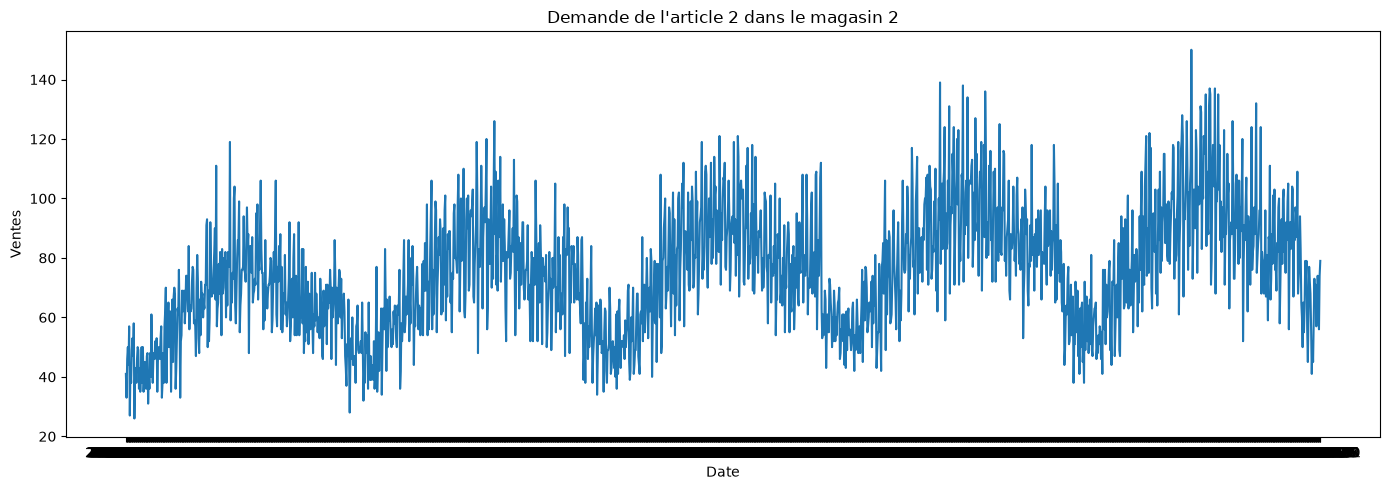

In [41]:
plt.figure(figsize=(14,5))
plt.plot(serie2_2['date'],serie2_2['sales'])
plt.title('Demande de l\'article 2 dans le magasin 2')
plt.xlabel('Date')
plt.ylabel('Ventes')
plt.tight_layout()
plt.show()

In [ ]:
df.info()

In [44]:
df.head(100)
display(df)
df.iloc[1826:1899]


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


,date,store,item,sales
1826,2013-01-01,2,1,12
1827,2013-01-02,2,1,16
1828,2013-01-03,2,1,16
1829,2013-01-04,2,1,20
1830,2013-01-05,2,1,16
...,...,...,...,...
1894,2013-03-10,2,1,32
1895,2013-03-11,2,1,17
1896,2013-03-12,2,1,20
1897,2013-03-13,2,1,22


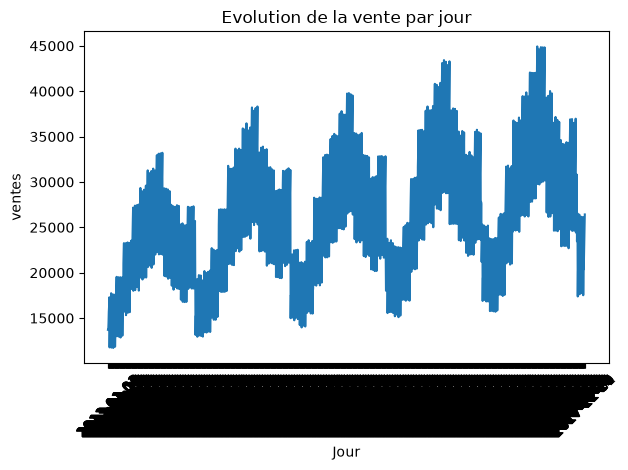

In [52]:
#Ventes totales sur tous les magasins tous produits confondus par jour
ventes_journalieres =df.groupby('date')['sales'].sum()
ventes_journalieres = ventes_journalieres.copy()
ventes_journalieres.head(20)
plt.plot(ventes_journalieres.index,ventes_journalieres.values)
plt.title('Evolution de la vente par jour')
plt.xlabel('Jour')
plt.ylabel('ventes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
#Ventes par magasin
vente_par_magasin = df.groupby('store')['sales'].sum()
display(vente_par_magasin)
magasin_vend_plus = df.groupby('store')['sales'].sum()
display(magasin_vend_plus.sort_values(ascending=False))

store
1     4315603
2     6120128
3     5435144
4     5012639
5     3631016
6     3627670
7     3320009
8     5856169
9     5025976
10    5360158
Name: sales, dtype: int64

store
2     6120128
8     5856169
3     5435144
10    5360158
9     5025976
4     5012639
1     4315603
5     3631016
6     3627670
7     3320009
Name: sales, dtype: int64

In [ ]:
#ventes par articles 
vente_par_article= df.groupby('item')['sales'].sum()
display(vente_par_article)
#articles les plus vendus
articles_plus_vendus = vente_par_article.sort_values(ascending=False).head()
display('Les articles les plus vendus')
display(articles_plus_vendus)


item
1      401384
2     1069564
3      669087
4      401907
5      335230
6     1068281
7     1068777
8     1405108
9      938379
10    1337133
11    1271925
12    1271534
13    1539621
14    1071531
15    1607442
16     468480
17     602486
18    1538876
19     736892
20     867641
21     736190
22    1469971
23     534979
24    1205975
25    1473334
26     869981
27     402628
28    1604713
29    1271240
30     736554
31    1070845
32     803107
33    1270183
34     469935
35    1201541
36    1406548
37     534258
38    1470330
39     801311
40     534094
41     401759
42     669925
43     936635
44     536811
45    1471467
46    1070764
47     401781
48     937703
49     535663
50    1203009
Name: sales, dtype: int64

'Les articles les plus vendus'

item
15    1607442
28    1604713
13    1539621
18    1538876
25    1473334
Name: sales, dtype: int64

In [7]:
serie2_2 = df[(df['store']==2 )& (df['item']==2)]

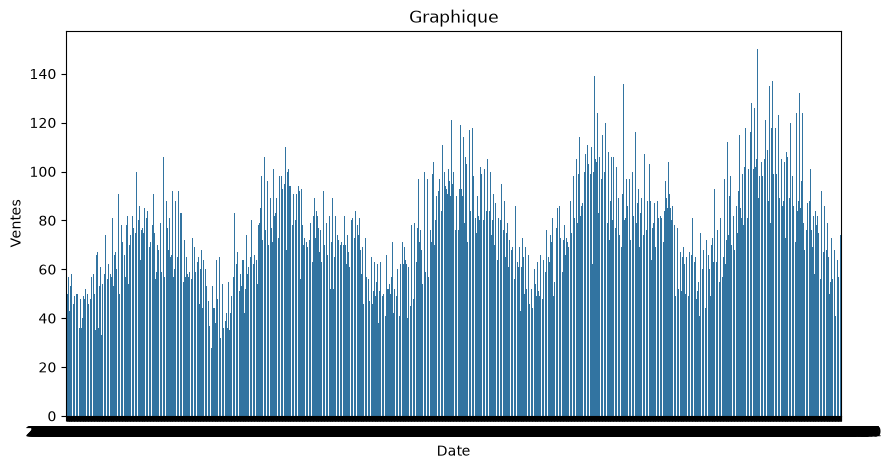

In [10]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(data=serie2_2,x='date', y='sales')

plt.title('Graphique')
plt.xlabel('Date')
plt.ylabel('Ventes')
plt.show()

In [11]:
serie2_2['sales'].mean()

np.float64(75.31653888280394)

In [12]:
serie2_22 = serie2_2.copy()
display(serie2_22.tail(100))

,date,store,item,sales
21812,2017-09-23,2,2,100
21813,2017-09-24,2,2,132
21814,2017-09-25,2,2,75
21815,2017-09-26,2,2,80
21816,2017-09-27,2,2,85
...,...,...,...,...
21907,2017-12-27,2,2,74
21908,2017-12-28,2,2,69
21909,2017-12-29,2,2,56
21910,2017-12-30,2,2,74


In [16]:
serie1_2=df[(df['store']==1) & (df['item']==2)]
serie1_2

,date,store,item,sales
18260,2013-01-01,1,2,33
18261,2013-01-02,1,2,43
18262,2013-01-03,1,2,23
18263,2013-01-04,1,2,18
18264,2013-01-05,1,2,34
...,...,...,...,...
20081,2017-12-27,1,2,55
20082,2017-12-28,1,2,50
20083,2017-12-29,1,2,50
20084,2017-12-30,1,2,56


In [17]:
print(serie1_2['sales'].mean())

53.14895947426068
